In [1]:
from pathlib import Path
from typing import Optional

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
tqdm.pandas()

In [2]:
def find_project_root(start: Optional[Path] = None) -> Path:
    start = start or Path.cwd()
    candidates = [start, start.parent]

    for candidate in candidates:
        if (candidate / 'data' / 'images' / 'orga_widecrop').exists():
            return candidate
        
    raise FileNotFoundError('Impossible de trouver la racine du projet à partir de la position courante.')

In [3]:
PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / 'data' / 'images'
WIDE_ROOT = DATA_ROOT / 'orga_widecrop'
CROP_ROOT = DATA_ROOT / 'orga_cropping'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'manifests'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Racine du projet : {PROJECT_ROOT}')
print(f'Wide root : {WIDE_ROOT}')
print(f'Crop root : {CROP_ROOT}')

Racine du projet : c:\Users\Jules\Documents\IEES\idmybee
Wide root : c:\Users\Jules\Documents\IEES\idmybee\data\images\orga_widecrop
Crop root : c:\Users\Jules\Documents\IEES\idmybee\data\images\orga_cropping


## Localisation du crop dans le wide

In [4]:
manifest = pd.read_csv(OUTPUT_DIR / 'manifest.csv', index_col='id')
clean_pairs = manifest[manifest['statut'] == 'paire_propre'].copy()

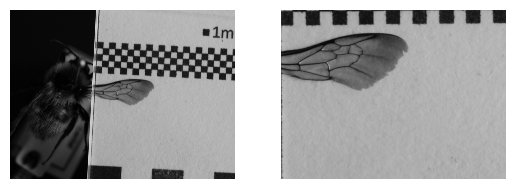

In [5]:
pair = clean_pairs.loc["FR15ABOM210821110_P1"]

wide_path = PROJECT_ROOT / pair["chemin_wide"]
crop_path = PROJECT_ROOT / pair['chemin_crop_large']

wide = cv2.imread(str(wide_path), cv2.IMREAD_COLOR)
crop = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)

wide_gray = cv2.cvtColor(wide, cv2.COLOR_BGR2GRAY)
crop_gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

fig, (ax1, ax2) = plt.subplots(1,2)
ax1.imshow(cv2.cvtColor(wide_gray, cv2.COLOR_BGR2RGB))
ax2.imshow(cv2.cvtColor(crop_gray, cv2.COLOR_BGR2RGB))

ax1.axis('off')
ax2.axis('off')

plt.show()

### Match Template

max_val:  0.7610807418823242


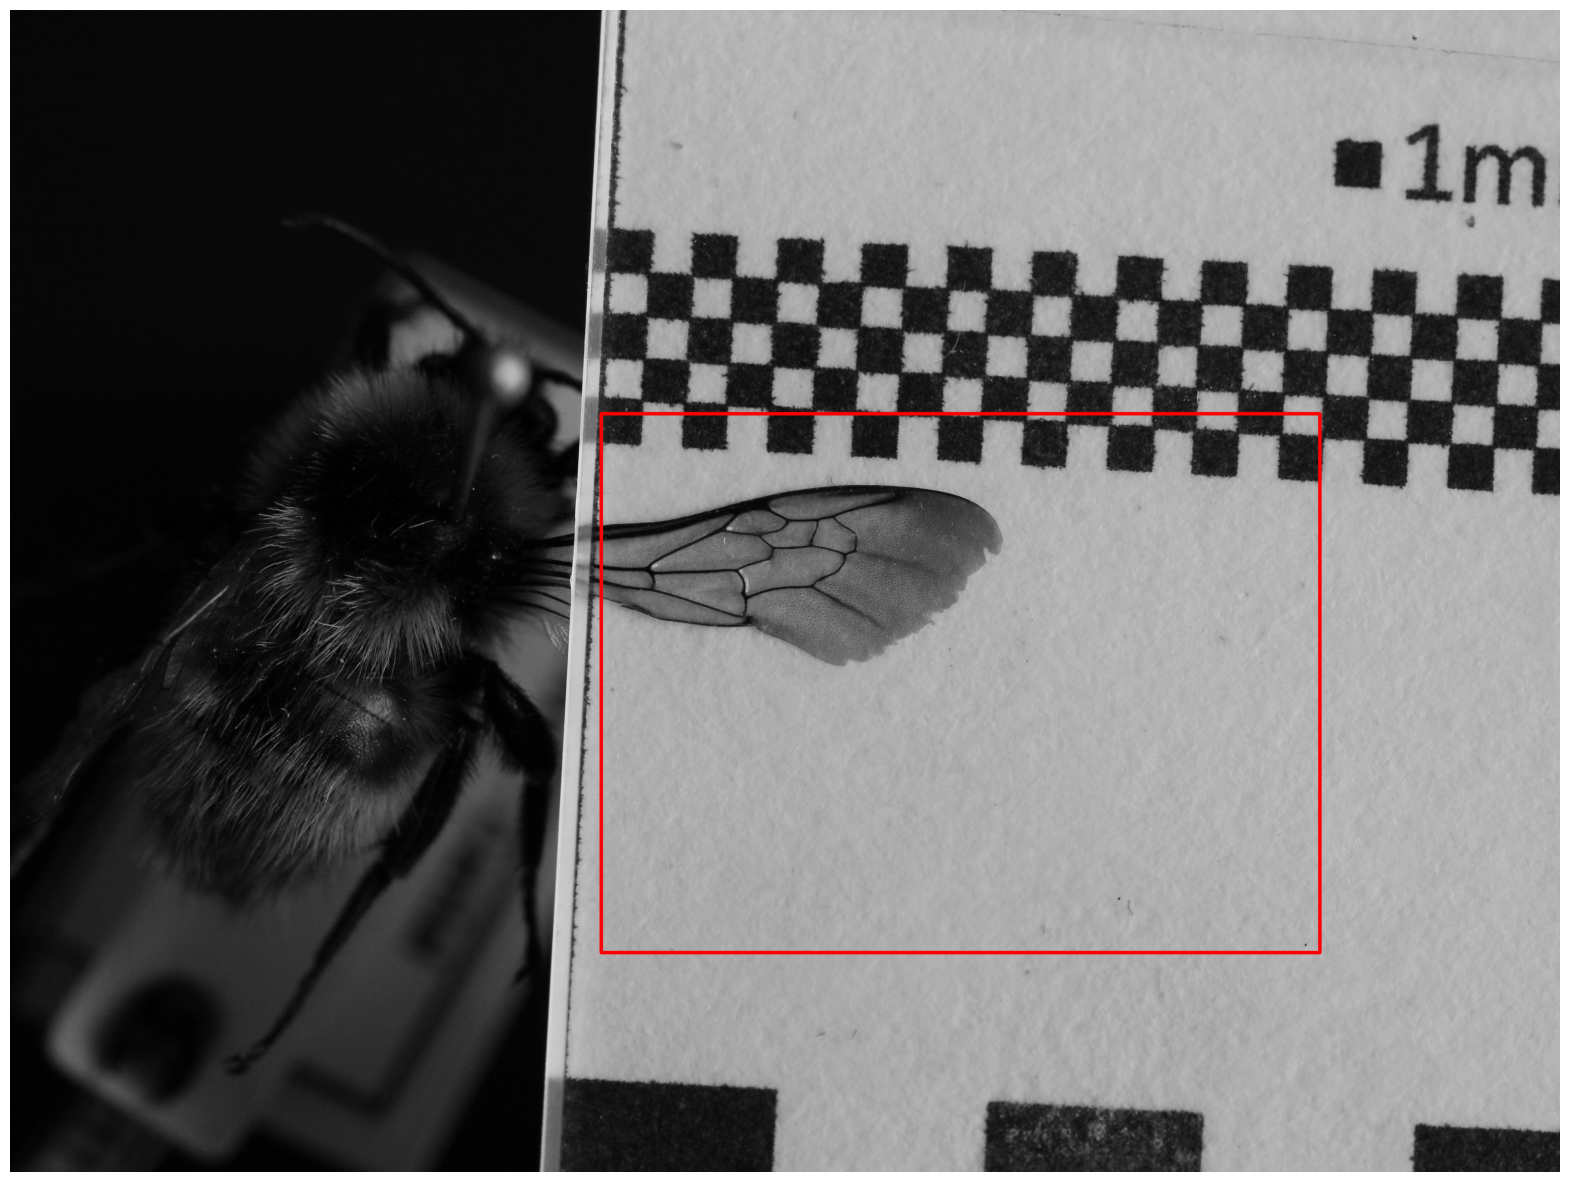

In [6]:
result = cv2.matchTemplate(wide_gray, crop_gray, cv2.TM_CCOEFF_NORMED)
_, max_val, _, max_loc = cv2.minMaxLoc(result)
startX, startY = max_loc

endX = startX + crop_gray.shape[1]
endY = startY + crop_gray.shape[0]

print("max_val: ", max_val)

im = cv2.cvtColor(wide_gray, cv2.COLOR_BGR2RGB)
cv2.rectangle(im, (startX, startY), (endX, endY), (0, 0, 255), 10)

plt.figure(figsize=(20,20))
plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### BF Matcher

In [7]:
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(wide_gray, None)
kp2, des2 = orb.detectAndCompute(crop_gray, None)

In [8]:
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = matcher.match(des1, des2)

In [9]:
final_img = cv2.drawMatches(wide_gray, kp1, crop_gray, kp2, matches[:20], None)
final_img = cv2.resize(final_img, None, fx=0.2, fy=0.2)

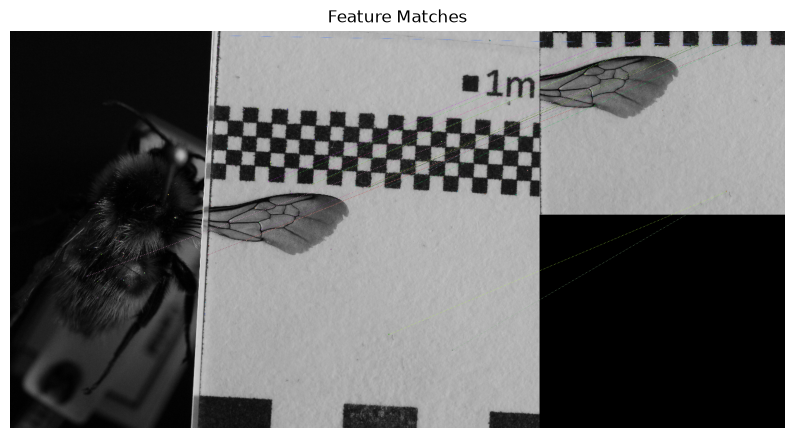

In [10]:
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)) 
plt.title("Feature Matches")
plt.axis('off')
plt.show()